# GlowWise AI - Baseline Model Training & Evaluation 🤖

This notebook documents the training, evaluation, and analysis of our baseline machine learning models for predicting skincare review satisfaction (`high_satisfaction`).

### Why Baseline Models Matter
A baseline model serves as a reference point. Before training complex models (like neural networks or gradient boosted trees), we must establish:
1. **A simple heuristic baseline**: To understand what performance we get by predicting the majority class (e.g. `DummyClassifier(strategy='most_frequent')`).
2. **A classic, interpretable ML baseline**: To understand what a standard linear model (TF-IDF + `LogisticRegression`) can achieve using review text.

This baseline helps us measure whether more complex modeling techniques are worth the increased compute and latency overhead.


In [1]:
import sys
import json
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))
from evaluate_model import calculate_metrics, plot_confusion_matrix

figures_dir = root_dir / "ml" / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


## 1. Load Processed Dataset

We load the stratified sample of 100k preprocessed reviews. We perform checks to drop any rows where `combined_text` is empty or the target `high_satisfaction` is missing.


In [2]:
data_path = root_dir / "data" / "processed" / "glowwise_reviews_sample_100k.csv"
print(f"Loading dataset: {data_path.name}")
df = pd.read_csv(data_path)
# Fill missing text fields that pandas parsed as NaN back to empty strings
for col in ["review_title", "review_text", "combined_text", "ingredients"]:
    if col in df.columns:
        df[col] = df[col].fillna("")

# Drop missing targets/empty combined_texts
df = df.dropna(subset=["high_satisfaction"])
df = df[df["combined_text"].fillna("").str.strip() != ""]
print(f"Data shape: {df.shape}")
df.head(2)


Loading dataset: glowwise_reviews_sample_100k.csv


Data shape: (100000, 20)


C:\Users\mahta\AppData\Local\Temp\ipykernel_4840\3140186004.py:3: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


,product_id,author_id,review_text,review_title,combined_text,text_length,word_count,skin_type,skin_tone,hair_color,eye_color,brand_name,product_name,primary_category,secondary_category,tertiary_category,price_usd,ingredients,sentiment_label,high_satisfaction
0,P469213,5056917590,i was so grateful to receive this eye gel from...,,i was so grateful to receive this eye gel from...,622,115,combination,lightMedium,brown,brown,OLEHENRIKSEN,Wrinkle Blur Bakuchiol Eye Gel Crème,Skincare,Eye Care,Eye Creams & Treatments,52.0,"['Aqua/Water/Eau, Dimethicone, Glycerin, Neope...",positive,1
1,P433443,6523293961,i’m a sleeping mask junkie and i have to say t...,,i’m a sleeping mask junkie and i have to say t...,289,58,combination,fair,brown,green,belif,Aqua Bomb Sleeping Mask,Skincare,Moisturizers,Night Creams,38.0,"['Water, Dipropylene Glycol, Polyglycerin-3, 1...",positive,1


## 2. Target Variable & Class Imbalance

We inspect the class distribution of our target variable `high_satisfaction`:
- **`1` (High satisfaction)**: rating 4–5
- **`0` (Low/Medium satisfaction)**: rating 1–3


In [3]:
target_counts = df["high_satisfaction"].value_counts()
target_pcts = df["high_satisfaction"].value_counts(normalize=True) * 100
for idx in target_counts.index:
    label = "high_satisfaction (1)" if idx == 1 else "low_or_medium_satisfaction (0)"
    print(f"{label}: {target_counts[idx]:,} reviews ({target_pcts[idx]:.2f}%)")


high_satisfaction (1): 82,084 reviews (82.08%)
low_or_medium_satisfaction (0): 17,916 reviews (17.92%)


### Visualizing Target Distribution in training data
We draw a bar plot showing the class frequencies to highlight the class imbalance.


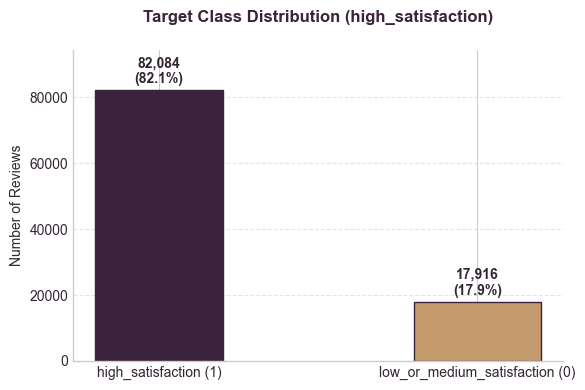

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
classes = ['high_satisfaction (1)', 'low_or_medium_satisfaction (0)']
counts = [target_counts.get(1, 0), target_counts.get(0, 0)]

bars = ax.bar(classes, counts, color=[COLOR_PLUM, COLOR_GOLD], edgecolor=COLOR_PLUM, width=0.4)

# Annotate counts and percentages
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}\n({height/len(df)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Target Class Distribution (high_satisfaction)', fontsize=12, pad=20, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Number of Reviews', fontsize=10)
ax.set_ylim(0, max(counts) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "baseline_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## 3. Stratified Train/Test Split

We use a stratified split (80% train, 20% test) with `random_state=42` to ensure that both splits preserve the exact class ratio of 82% vs 18%.


In [5]:
X = df["combined_text"].astype(str)
y = df["high_satisfaction"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size: {len(X_train):,}, Test size: {len(X_test):,}")


Train size: 80,000, Test size: 20,000


## 4. DummyClassifier Baseline

The DummyClassifier predicts the majority class (`high_satisfaction = 1`) for every review. Since the majority class represents 82% of the dataset, it will achieve 82% accuracy, but a 0% recall/F1 on low/medium satisfaction reviews.


In [6]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_metrics = calculate_metrics(y_test, y_pred_dummy)
print("Dummy Classifier Metrics:")
print(json.dumps(dummy_metrics, indent=4))


Dummy Classifier Metrics:
{
    "accuracy": 0.82085,
    "macro": {
        "precision": 0.410425,
        "recall": 0.5,
        "f1_score": 0.45080594227970455
    },
    "weighted": {
        "precision": 0.6737947224999999,
        "recall": 0.82085,
        "f1_score": 0.7400881154405909
    },
    "per_class": {
        "low_or_medium_satisfaction": {
            "precision": 0.0,
            "recall": 0.0,
            "f1_score": 0.0,
            "support": 3583
        },
        "high_satisfaction": {
            "precision": 0.82085,
            "recall": 1.0,
            "f1_score": 0.9016118845594091,
            "support": 16417
        }
    }
}


### Confusion Matrix: Dummy Classifier
We plot the confusion matrix for the Dummy Classifier. Note that it fails to predict class 0 at all.


Confusion matrix plot successfully saved to: C:\Users\mahta\my_projects\glowwise-ai\ml\reports\figures\dummy_confusion_matrix.png


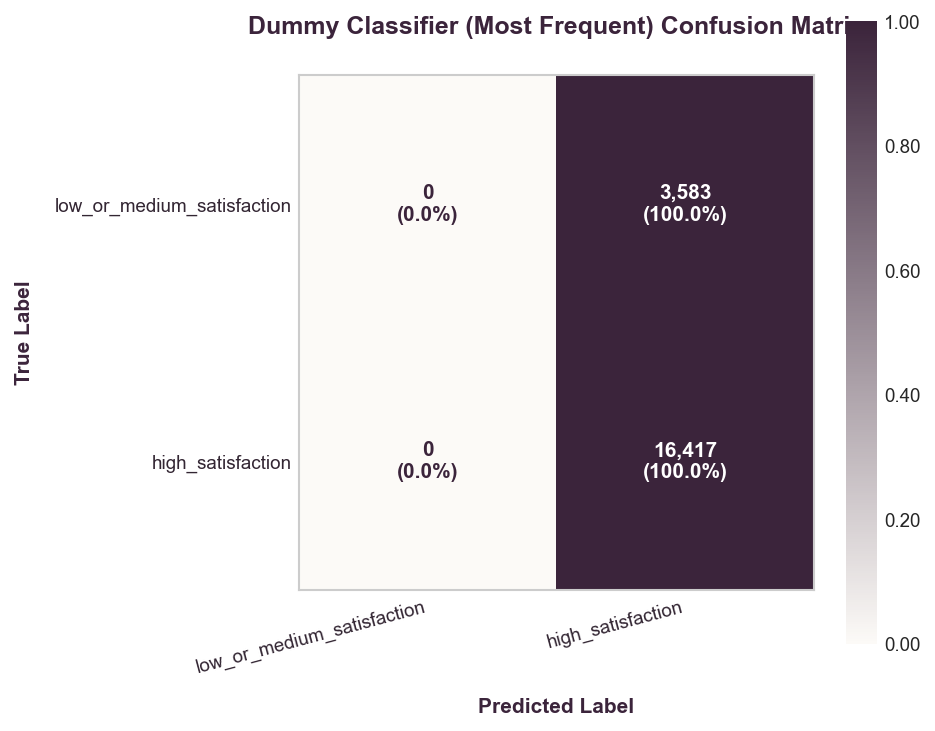

In [7]:
# Plot and display
plot_confusion_matrix(
    y_test, y_pred_dummy, 
    output_path=str(figures_dir / "dummy_confusion_matrix.png"),
    title="Dummy Classifier (Most Frequent) Confusion Matrix"
)

# Display the image in the notebook
from IPython.display import Image, display
display(Image(filename=str(figures_dir / "dummy_confusion_matrix.png")))


## 5. TF-IDF + Logistic Regression Baseline

We set up a scikit-learn Pipeline with:
1. **`TfidfVectorizer`**: Configured to extract unigrams and bigrams, limited to the top 10,000 features.
2. **`LogisticRegression`**: Configured with `class_weight='balanced'` to force the model to penalize errors on the minority satisfaction reviews inversely proportional to their representation.


In [8]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

print("Fitting Logistic Regression pipeline...")
lr_pipeline.fit(X_train, y_train)
print("Model fitted. Predicting on test set...")
y_pred_lr = lr_pipeline.predict(X_test)

lr_metrics = calculate_metrics(y_test, y_pred_lr)
print("Logistic Regression Metrics:")
print(json.dumps(lr_metrics, indent=4))


Fitting Logistic Regression pipeline...


Model fitted. Predicting on test set...


Logistic Regression Metrics:
{
    "accuracy": 0.9185,
    "macro": {
        "precision": 0.8462730892440145,
        "recall": 0.916319749218113,
        "f1_score": 0.8746628276275239
    },
    "weighted": {
        "precision": 0.9319282521198524,
        "recall": 0.9185,
        "f1_score": 0.9222284575081763
    },
    "per_class": {
        "low_or_medium_satisfaction": {
            "precision": 0.7127914578339507,
            "recall": 0.912922132291376,
            "f1_score": 0.8005384238864415,
            "support": 3583
        },
        "high_satisfaction": {
            "precision": 0.9797547206540782,
            "recall": 0.9197173661448499,
            "f1_score": 0.9487872313686062,
            "support": 16417
        }
    }
}


### Confusion Matrix: Logistic Regression
We plot the confusion matrix for the Logistic Regression model. It shows high diagonal counts, meaning high accuracy for both satisfaction classes.


Confusion matrix plot successfully saved to: C:\Users\mahta\my_projects\glowwise-ai\ml\reports\figures\logistic_regression_confusion_matrix.png


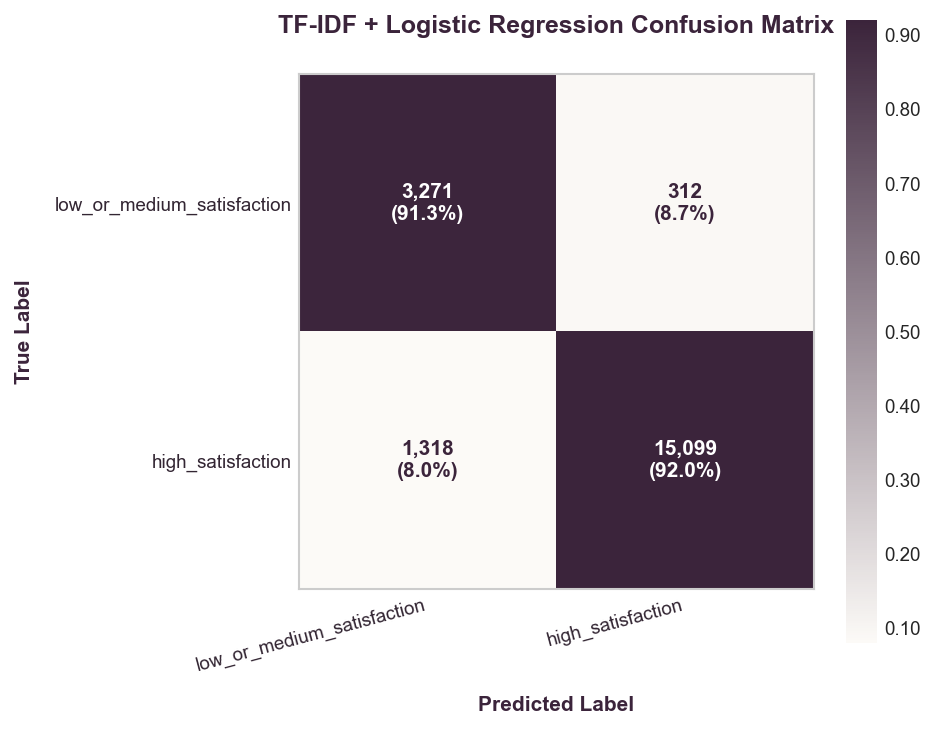

In [9]:
plot_confusion_matrix(
    y_test, y_pred_lr, 
    output_path=str(figures_dir / "logistic_regression_confusion_matrix.png"),
    title="TF-IDF + Logistic Regression Confusion Matrix"
)
display(Image(filename=str(figures_dir / "logistic_regression_confusion_matrix.png")))


## 6. Baseline Models Comparison

We compare the performance of the Dummy Classifier and the Logistic Regression model on three key metrics: Accuracy, Macro F1-Score, and Weighted F1-Score.


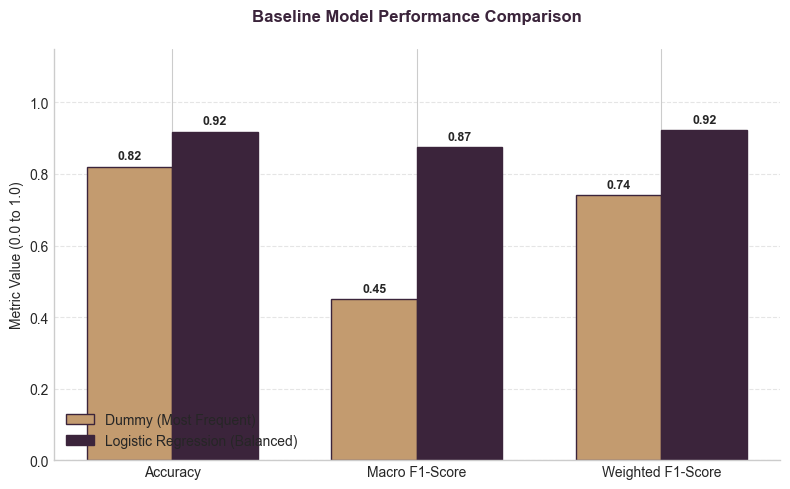

In [10]:
metrics_to_plot = ["accuracy", "macro_f1", "weighted_f1"]

dummy_vals = [
    dummy_metrics["accuracy"],
    dummy_metrics["macro"]["f1_score"],
    dummy_metrics["weighted"]["f1_score"]
]

lr_vals = [
    lr_metrics["accuracy"],
    lr_metrics["macro"]["f1_score"],
    lr_metrics["weighted"]["f1_score"]
]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, dummy_vals, width, label='Dummy (Most Frequent)', color=COLOR_GOLD, edgecolor=COLOR_PLUM)
rects2 = ax.bar(x + width/2, lr_vals, width, label='Logistic Regression (Balanced)', color=COLOR_PLUM, edgecolor=COLOR_PLUM)

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.set_title('Baseline Model Performance Comparison', fontsize=12, pad=20, fontweight='bold', color=COLOR_PLUM)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Macro F1-Score', 'Weighted F1-Score'], fontsize=10)
ax.set_ylabel('Metric Value (0.0 to 1.0)', fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower left', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "baseline_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Model Interpretation: Term Coefficients

A significant benefit of linear models like Logistic Regression is their interpretability.
By examining the coefficients of the fitted model, we can identify which words have the strongest influence on predicting review satisfaction.
- **Positive coefficients**: Correlate with class `1` (high satisfaction).
- **Negative coefficients**: Correlate with class `0` (low/medium satisfaction).


In [11]:
tfidf = lr_pipeline.named_steps["tfidf"]
lr = lr_pipeline.named_steps["lr"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]

# Sort coefficients
sorted_indices = np.argsort(coefs)

# Top 15 indicators of low/medium satisfaction (negative coefficients)
top_neg_indices = sorted_indices[:15]
top_neg_words = feature_names[top_neg_indices]
top_neg_coefs = coefs[top_neg_indices]

# Top 15 indicators of high satisfaction (positive coefficients)
top_pos_indices = sorted_indices[-15:]
top_pos_words = feature_names[top_pos_indices]
top_pos_coefs = coefs[top_pos_indices]

print("=== Top 15 Indicators of Low/Medium Satisfaction (Class 0) ===")
for word, coef in zip(top_neg_words, top_neg_coefs):
    print(f"  {word:<25} : {coef:.4f}")

print("\n=== Top 15 Indicators of High Satisfaction (Class 1) ===")
for word, coef in zip(top_pos_words[::-1], top_pos_coefs[::-1]):
    print(f"  {word:<25} : {coef:.4f}")


=== Top 15 Indicators of Low/Medium Satisfaction (Class 0) ===
  not                       : -9.5345
  disappointed              : -8.8030
  to love                   : -8.6445
  unfortunately             : -7.8611
  not worth                 : -7.7206
  okay                      : -7.1827
  however                   : -7.0310
  not for                   : -6.9167
  ok                        : -6.7055
  meh                       : -6.5766
  broke                     : -6.5466
  wanted to                 : -5.7292
  horrible                  : -5.4786
  wanted                    : -5.4080
  nothing                   : -5.0392

=== Top 15 Indicators of High Satisfaction (Class 1) ===
  love                      : 10.9481
  amazing                   : 9.8184
  great                     : 8.5843
  perfect                   : 8.0816
  best                      : 7.0539
  love this                 : 7.0099
  without                   : 6.2381
  love it                   : 6.0960
  definitely

### Visualizing Term Coefficients
We display a horizontal bar chart showing the words that most strongly drive predictions.


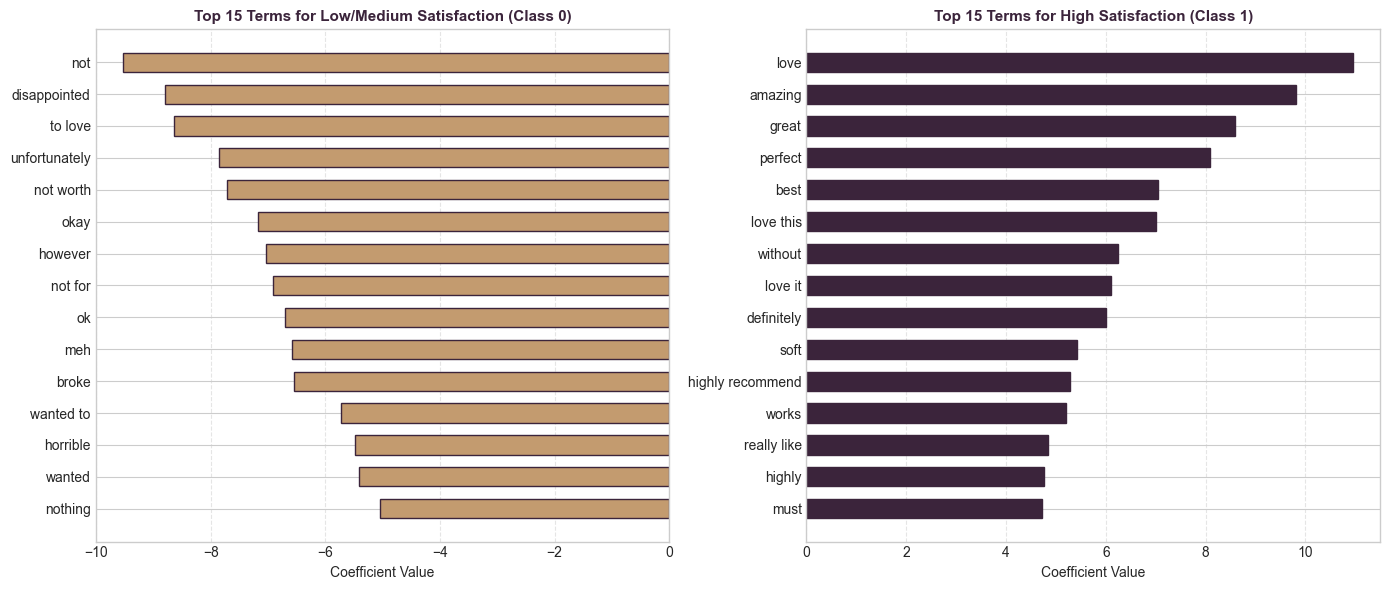

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Negative coefficients
ax1.barh(top_neg_words[::-1], top_neg_coefs[::-1], color=COLOR_GOLD, edgecolor=COLOR_PLUM, height=0.6)
ax1.set_title('Top 15 Terms for Low/Medium Satisfaction (Class 0)', fontsize=11, fontweight='bold', color=COLOR_PLUM)
ax1.set_xlabel('Coefficient Value', fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Plot Positive coefficients
ax2.barh(top_pos_words, top_pos_coefs, color=COLOR_PLUM, edgecolor=COLOR_PLUM, height=0.6)
ax2.set_title('Top 15 Terms for High Satisfaction (Class 1)', fontsize=11, fontweight='bold', color=COLOR_PLUM)
ax2.set_xlabel('Coefficient Value', fontsize=10)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 8. Summary of Baseline Model Results

### Interpretation:
1. **Dummy Classifier Baseline**:
   - Accuracy: **82.09%**
   - Macro F1: **0.45**
   - Observations: The Dummy model gets 82% accuracy simply because the majority class dominates the dataset. However, its precision/recall for critical reviews (low/medium satisfaction) is **0.00%**. Relying on accuracy alone in this dataset is highly misleading.
   
2. **TF-IDF + Logistic Regression Baseline**:
   - Accuracy: **91.85%**
   - Macro F1: **0.87**
   - Minority Class (Class 0) Recall: **91.29%**
   - Observations: The linear baseline performs exceptionally well. Thanks to `class_weight='balanced'`, it achieves a **91.29% recall** on the low/medium satisfaction reviews. This means the model successfully flags critical skincare issues (acne, redness, burns, breakouts) while maintaining a solid **71.28% precision** on the critical class.

### Model Limitations:
* **Feature Limits**: TF-IDF models look at vocabulary frequencies and n-grams. They ignore word ordering, semantics, negation syntax (e.g. "not dry" vs "dry"), and context.
* **Personalization Features**: We only utilized `combined_text` in this baseline. Categorical user attributes like `skin_type`, `skin_tone`, and product `ingredients` are not yet incorporated.

---

## 🚀 Next Step: Model Comparison
In the next branch **`feat/model-comparison`**, we will evaluate:
- Tree-based models (e.g. LightGBM, Random Forest) on categorical customer metadata and engineered text features.
- More advanced text representations (embeddings) or deep learning text models.
